In [17]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Path to dataset files: /kaggle/input/imdb-dataset-of-50k-movie-reviews


In [18]:
import pandas as pd
import os

# List files in the downloaded path
print(f"Files in directory: {os.listdir(path)}")

# Load the dataset (usually named IMDB Dataset.csv)
csv_path = os.path.join(path, 'IMDB Dataset.csv')
df = pd.read_csv(csv_path)

# Display basic info and first few rows
print("Dataset Shape:", df.shape)
display(df.info())
display(df.head())

Files in directory: ['IMDB Dataset.csv']
Dataset Shape: (50000, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


None

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [22]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Download necessary NLTK data
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # 1. Lowercasing
    text = text.lower()

    # 2. Removing HTML tags (like <br />)
    text = re.sub(r'<.*?>', '', text)

    # 3. Removing URLs and special characters/punctuation
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'[^a-z\s]', '', text)

    # 4. Tokenization
    tokens = word_tokenize(text)

    # 5. Removing stopwords and Lemmatization
    cleaned_tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]

    return ' '.join(cleaned_tokens)

# Apply preprocessing to a subset or full dataset
# Note: Preprocessing 50k rows can take a few minutes.
print("Starting preprocessing...")
df['cleaned_review'] = df['review'].apply(preprocess_text)

print("Preprocessing complete.")
display(df[['review', 'cleaned_review']].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Starting preprocessing...
Preprocessing complete.


,review,cleaned_review
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching oz episode you...
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically there family little boy jake think t...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love time money visually stunni...


In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Check if 'cleaned_review' exists, if not, use 'review' as a fallback or raise a helpful message
if 'cleaned_review' not in df.columns:
    print("Error: 'cleaned_review' column not found. Please ensure the preprocessing cell (808078f2) has finished running successfully.")
else:
    # 1. Label Encoding for target variable
    le = LabelEncoder()
    df['sentiment_encoded'] = le.fit_transform(df['sentiment'])

    # 2. Split data into training and testing sets
    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        df['cleaned_review'], df['sentiment_encoded'], test_size=0.2, random_state=42
    )

    # 3. TF-IDF Vectorization
    tfidf = TfidfVectorizer(max_features=5000)
    X_train_tfidf = tfidf.fit_transform(X_train_raw)
    X_test_tfidf = tfidf.transform(X_test_raw)

    # 4. Bag of Words (BoW) Vectorization
    bow = CountVectorizer(max_features=5000)
    X_train_bow = bow.fit_transform(X_train_raw)
    X_test_bow = bow.transform(X_test_raw)

    print(f"TF-IDF Training Shape: {X_train_tfidf.shape}")
    print(f"BoW Training Shape: {X_train_bow.shape}")
    print("Feature Engineering complete.")

TF-IDF Training Shape: (40000, 5000)
BoW Training Shape: (40000, 5000)
Feature Engineering complete.


Missing values:
 review               0
sentiment            0
sentiment_encoded    0
cleaned_review       0
dtype: int64

Sentiment Distribution:
 sentiment
positive    25000
negative    25000
Name: count, dtype: int64


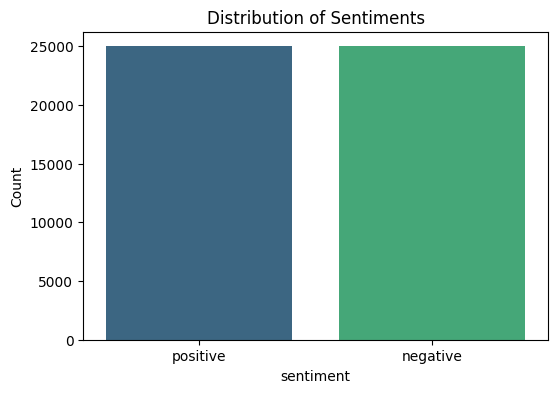

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check for missing values
print("Missing values:\n", df.isnull().sum())

# Check class distribution
sentiment_counts = df['sentiment'].value_counts()
print("\nSentiment Distribution:\n", sentiment_counts)

# Visualize the distribution
plt.figure(figsize=(6, 4))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis', hue=sentiment_counts.index, legend=False)
plt.title('Distribution of Sentiments')
plt.ylabel('Count')
plt.show()